In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = sns.load_dataset('titanic')

In [15]:
df["age"].head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [13]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [16]:
df['age']= df['age'].fillna(df['age'].median())

In [17]:
df["age"].head()

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0


In [18]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [26]:
df=df.drop(columns=['deck'])

In [27]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [28]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [30]:
df["embark_town"]= df["embark_town"].fillna(df["embark_town"].mode())

In [32]:
df.duplicated().sum()

np.int64(116)

In [35]:
df=df.drop_duplicates()

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [39]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


<Axes: xlabel='survived', ylabel='Count'>

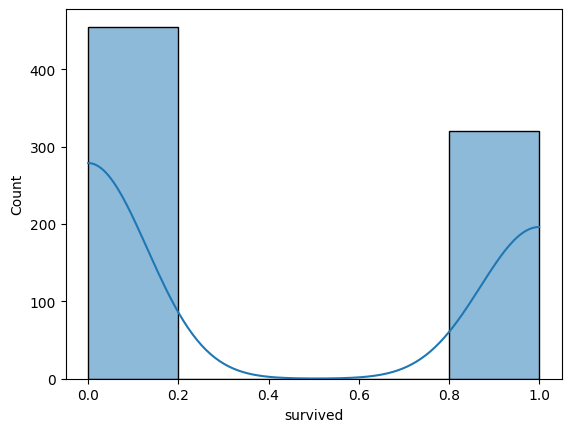

In [43]:
sns.histplot(x="survived",bins = 5,kde= True , data= df)

In [48]:
df["class"].value_counts()

,count
class,
Third,401
First,210
Second,164


<Axes: xlabel='survived', ylabel='class'>

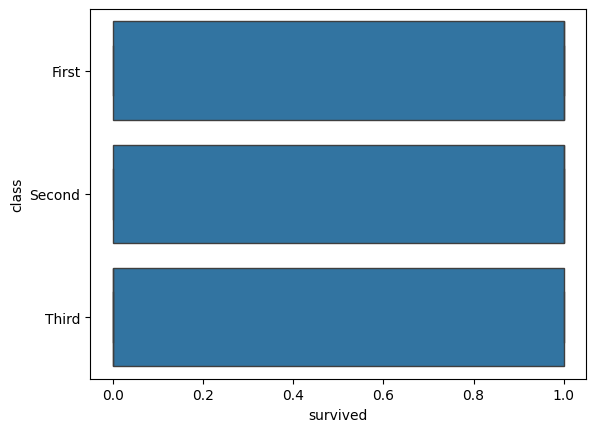

In [51]:
sns.boxplot(x="survived", y = "class" , data=df)

<Axes: xlabel='sex', ylabel='survived'>

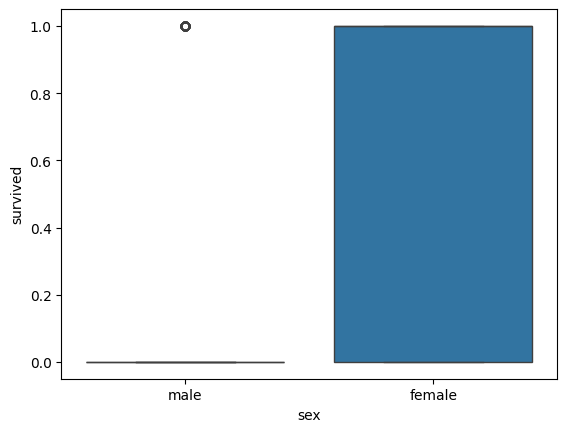

In [58]:
sns.boxplot(x="sex", y = "survived" , data=df)

<Axes: xlabel='survived', ylabel='sibsp'>

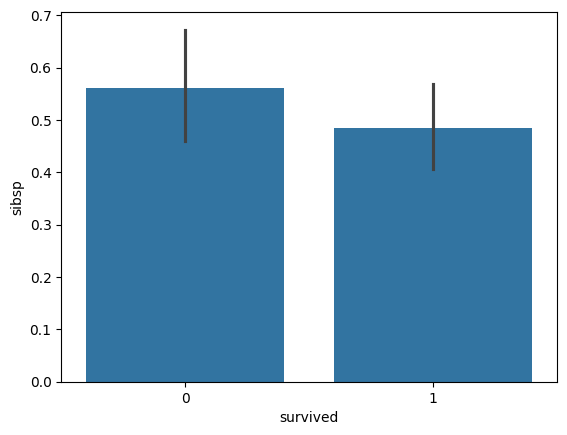

In [66]:
sns.barplot(x="survived", y = "sibsp" , data=df)

<Axes: xlabel='survived', ylabel='fare'>

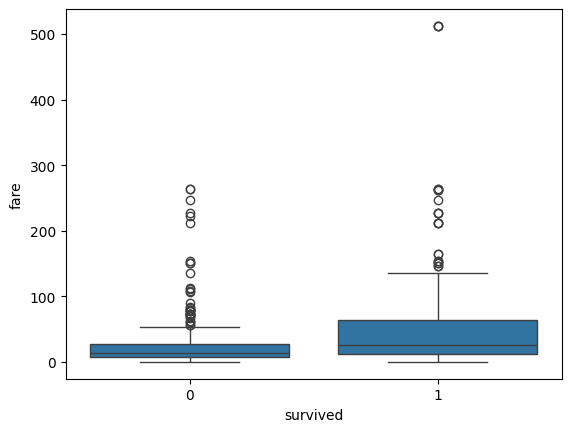

In [65]:
sns.boxplot(data=df,x ='survived', y = 'fare')

<Axes: >

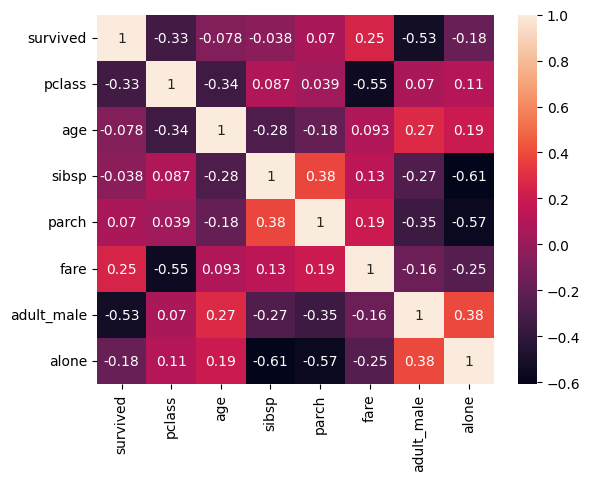

In [71]:
sns.heatmap(df.corr(numeric_only= True), annot = True)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     775 non-null    int64   
 1   pclass       775 non-null    int64   
 2   sex          775 non-null    object  
 3   age          775 non-null    float64 
 4   sibsp        775 non-null    int64   
 5   parch        775 non-null    int64   
 6   fare         775 non-null    float64 
 7   embarked     773 non-null    object  
 8   class        775 non-null    category
 9   who          775 non-null    object  
 10  adult_male   775 non-null    bool    
 11  embark_town  773 non-null    object  
 12  alive        775 non-null    object  
 13  alone        775 non-null    bool    
dtypes: bool(2), category(1), float64(2), int64(4), object(5)
memory usage: 75.1+ KB


In [75]:
x = df.drop(columns = "survived", axis =1)
y = df["survived"]

In [77]:
x_encode = pd.get_dummies(x, drop_first= True)

In [79]:
x_encode

,pclass,age,sibsp,parch,fare,adult_male,alone,sex_male,embarked_Q,embarked_S,class_Second,class_Third,who_man,who_woman,embark_town_Queenstown,embark_town_Southampton,alive_yes
0,3,22.0,1,0,7.2500,True,False,True,False,True,False,True,True,False,False,True,False
1,1,38.0,1,0,71.2833,False,False,False,False,False,False,False,False,True,False,False,True
2,3,26.0,0,0,7.9250,False,True,False,False,True,False,True,False,True,False,True,True
3,1,35.0,1,0,53.1000,False,False,False,False,True,False,False,False,True,False,True,True
4,3,35.0,0,0,8.0500,True,True,True,False,True,False,True,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,3,39.0,0,5,29.1250,False,False,False,True,False,False,True,False,True,True,False,False
887,1,19.0,0,0,30.0000,False,True,False,False,True,False,False,False,True,False,True,True
888,3,28.0,1,2,23.4500,False,False,False,False,True,False,True,False,True,False,True,False
889,1,26.0,0,0,30.0000,True,True,True,False,False,False,False,True,False,False,False,True


In [82]:
bool_col = x_encode.select_dtypes(include='bool').columns
x_encode[bool_col]=x_encode[bool_col].astype(int)

In [86]:
x_encode=x_encode.drop(columns=['alive_yes'])

In [87]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train-test split
x_train, x_test, y_train, y_test = train_test_split(
    x_encode, y, test_size=0.2, random_state=42
)

# Scaling (logistic regression scaled data pe better perform karta hai)
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model train karo
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train_scaled, y_train)

# Prediction
y_pred = log_model.predict(x_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8129032258064516
Confusion matrix:
 [[82 13]
 [16 44]]
Classification report:
               precision    recall  f1-score   support

           0       0.84      0.86      0.85        95
           1       0.77      0.73      0.75        60

    accuracy                           0.81       155
   macro avg       0.80      0.80      0.80       155
weighted avg       0.81      0.81      0.81       155

